In [198]:
import sys
sys.path.insert(0, '..')

In [199]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [200]:
wid = 58
oversample = 4

nwavels = 30#13#6
npoly=8

n_zernikes = 30

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"

vects_f110w = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects_f110w.shape == (nwavels, npoly)
spectrum_basis = vects_f110w/np.sqrt(np.mean(vects_f110w**2, axis=0))


ddir = "../data/MAST_2024-09-26T22_53_13.719Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n8ry01tkq_cal.fits", SinglePointFit(spectrum_basis, "F110W", precombined=False,), crop=wid),
    exposure_from_file(ddir + "n8ry01tmq_cal.fits", SinglePointFit(spectrum_basis, "F110W", precombined=False,), crop=wid),
    exposure_from_file(ddir + "n8ry02tpq_cal.fits", SinglePointFit(spectrum_basis, "F110W", precombined=False,), crop=wid),
    exposure_from_file(ddir + "n8ry02tqq_cal.fits", SinglePointFit(spectrum_basis, "F110W", precombined=False,), crop=wid),

        # exposure_from_file(ddir + "n8ry03vbq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry03vcq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry04vfq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry04vgq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vmq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vnq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    ##exposure_from_file(ddir + "n8ry06vpq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry06vqq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),


]


Version 4.4.1
207 60
Version 4.4.1
207 187
Version 4.4.1
206 51
Version 4.4.1
207 178


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This

In [201]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

52947.50036751
HZ4
F110W
319.9581
52947.50467306
HZ4
F110W
319.9581
52947.51977723
HZ4
F110W
319.9581
52947.52408278
HZ4
F110W
319.9581


In [202]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 79.68,
    "quadrature": {},
}



for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))/0.3
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

29.258964807502764
16.70181478630746
9.21746361298337
29.706443371856867


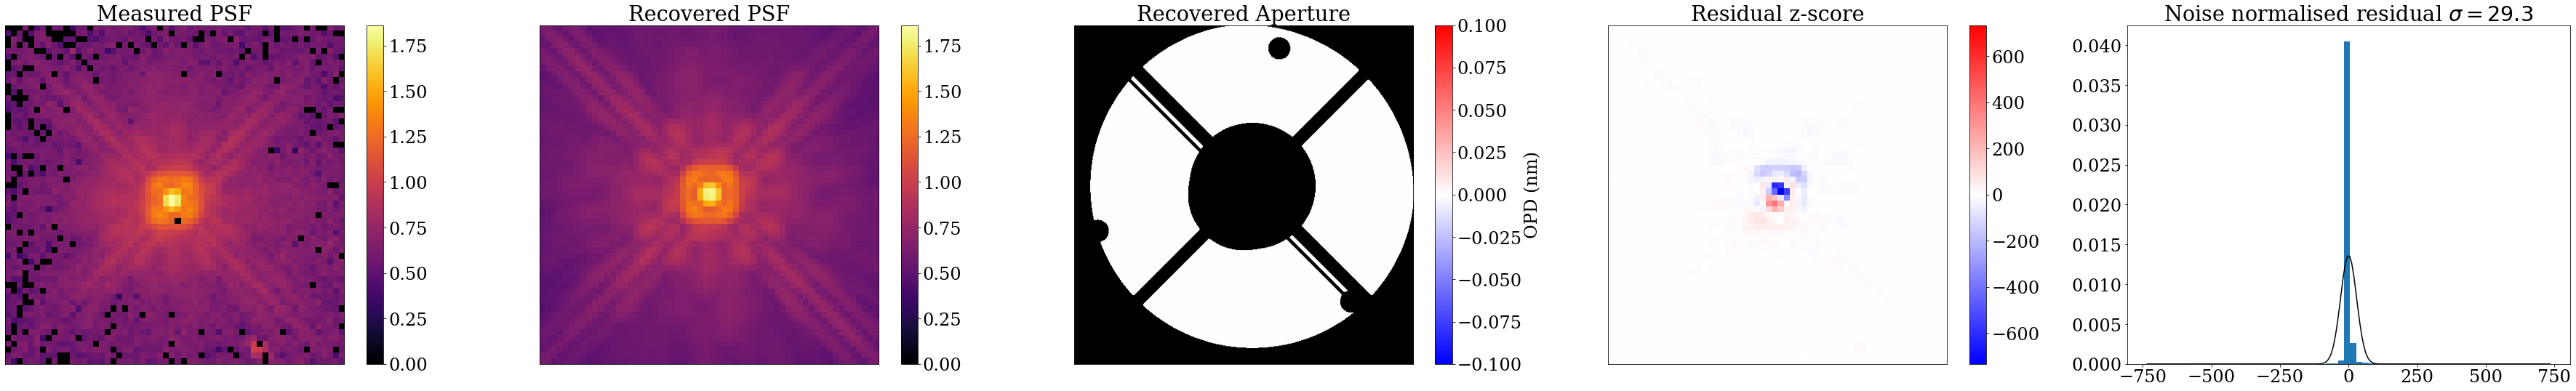

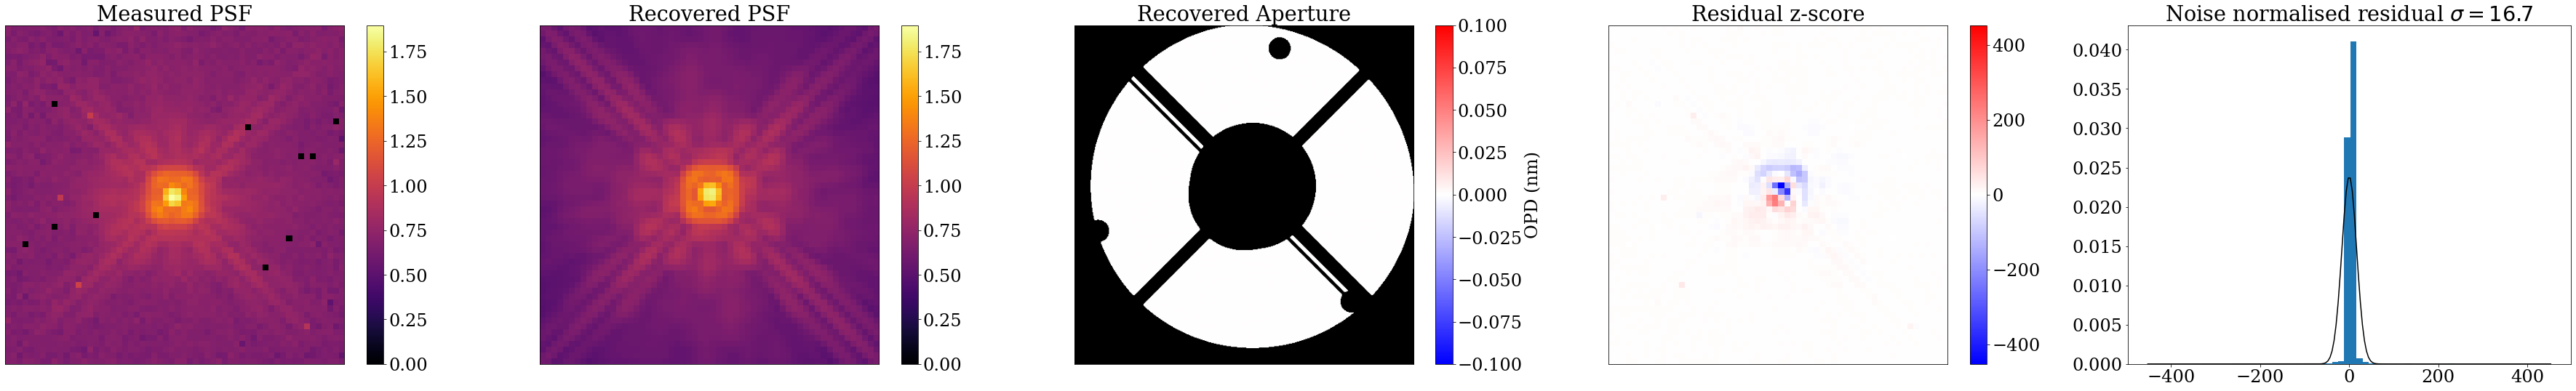

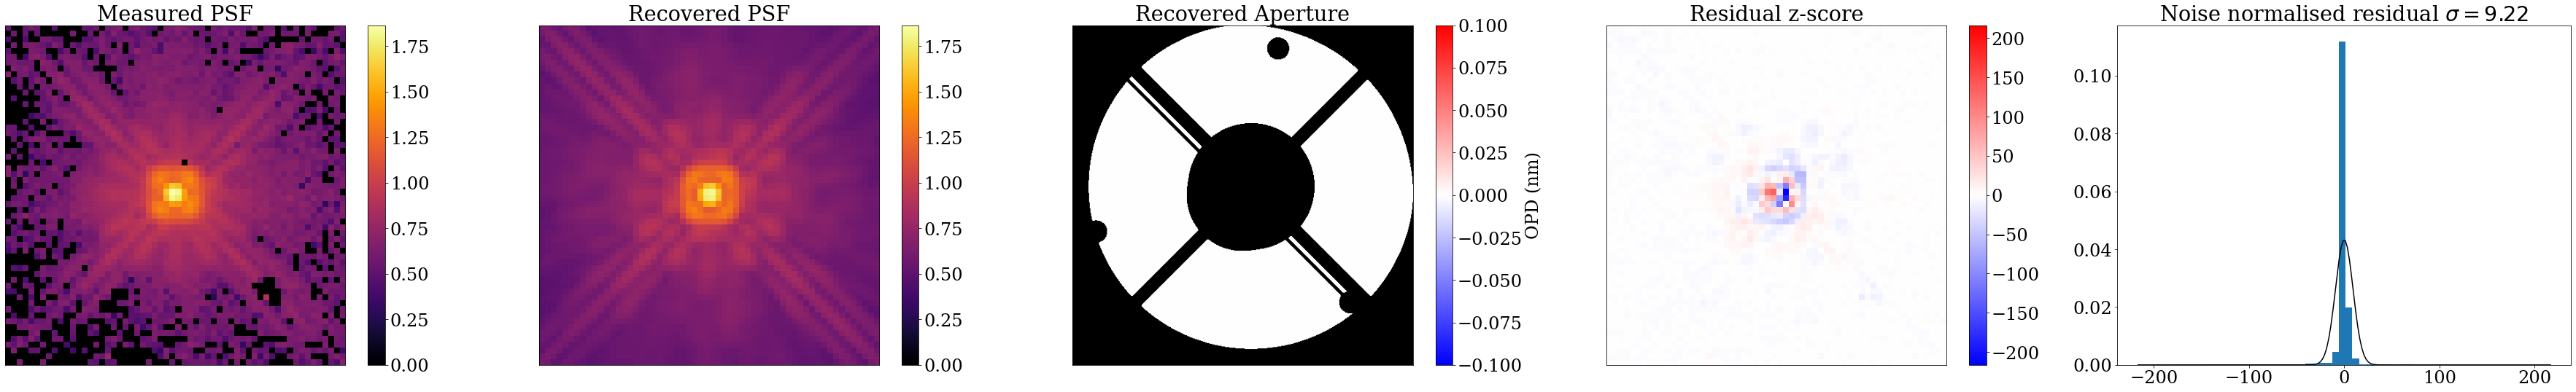

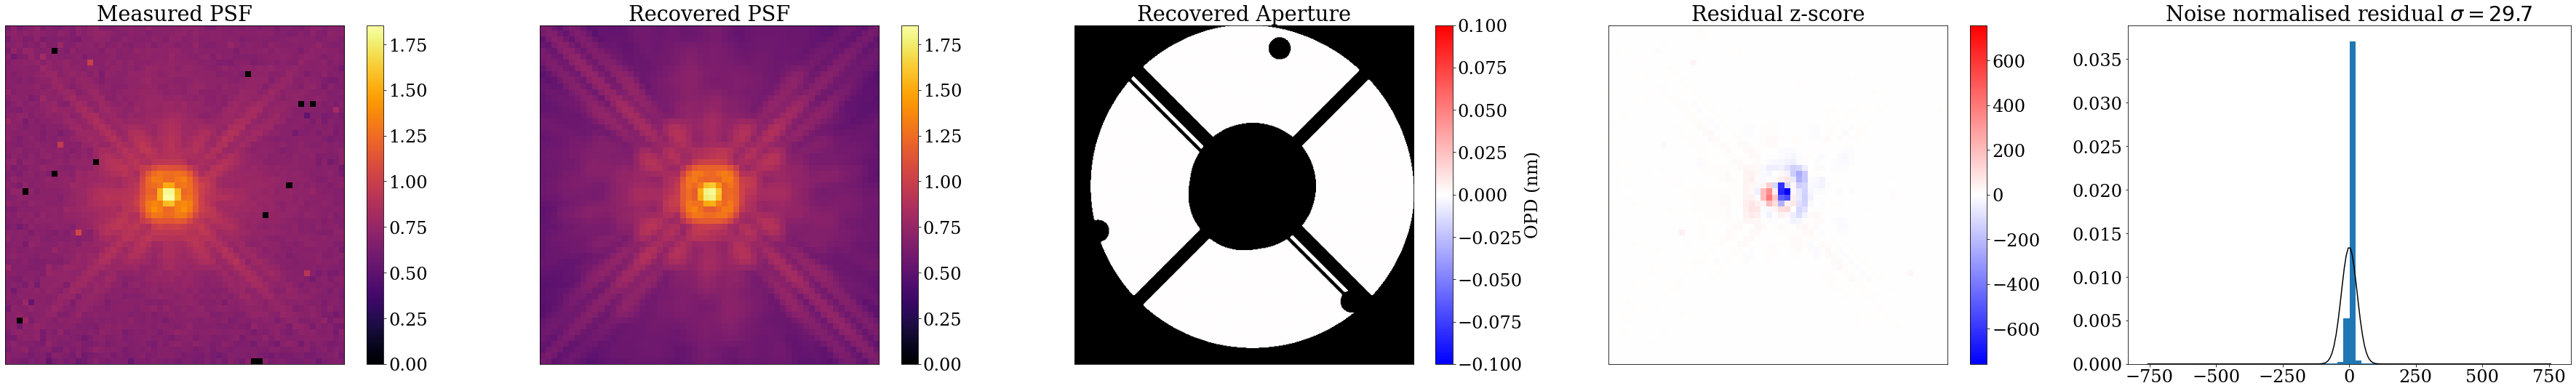

In [203]:
plot_comparison(model_single, params, exposures_single)

In [204]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*0.3, 10),
    "bias": sgd(g*3, 20),
    "cold_mask_shift": sgd(g*0.3, 30),
    "defocus": sgd(g*2, 30),
    "aberrations": sgd(g*0.08, 70),

    
    # #"fnumber": sgd(g*3, 100),
    # "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*25, 450),
}

things_start = {
    "positions": sgd(g*5, 0),
    "spectrum": sgd(g*0.2, 10),
}

groups = list(things.keys())

In [205]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [206]:
opt_params

{'positions': {'n8ry01tkq': Array([0., 0.], dtype=float64),
  'n8ry01tmq': Array([0., 0.], dtype=float64),
  'n8ry02tpq': Array([0., 0.], dtype=float64),
  'n8ry02tqq': Array([0., 0.], dtype=float64)},
 'spectrum': {'HZ4_F110W': Array([176.36706234,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ],      dtype=float64)}}

In [207]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 20)

  0%|          | 0/20 [00:00<?, ?it/s]

5.537627740622748
6.062279400221467
5.804486486799706
6.206782969458352


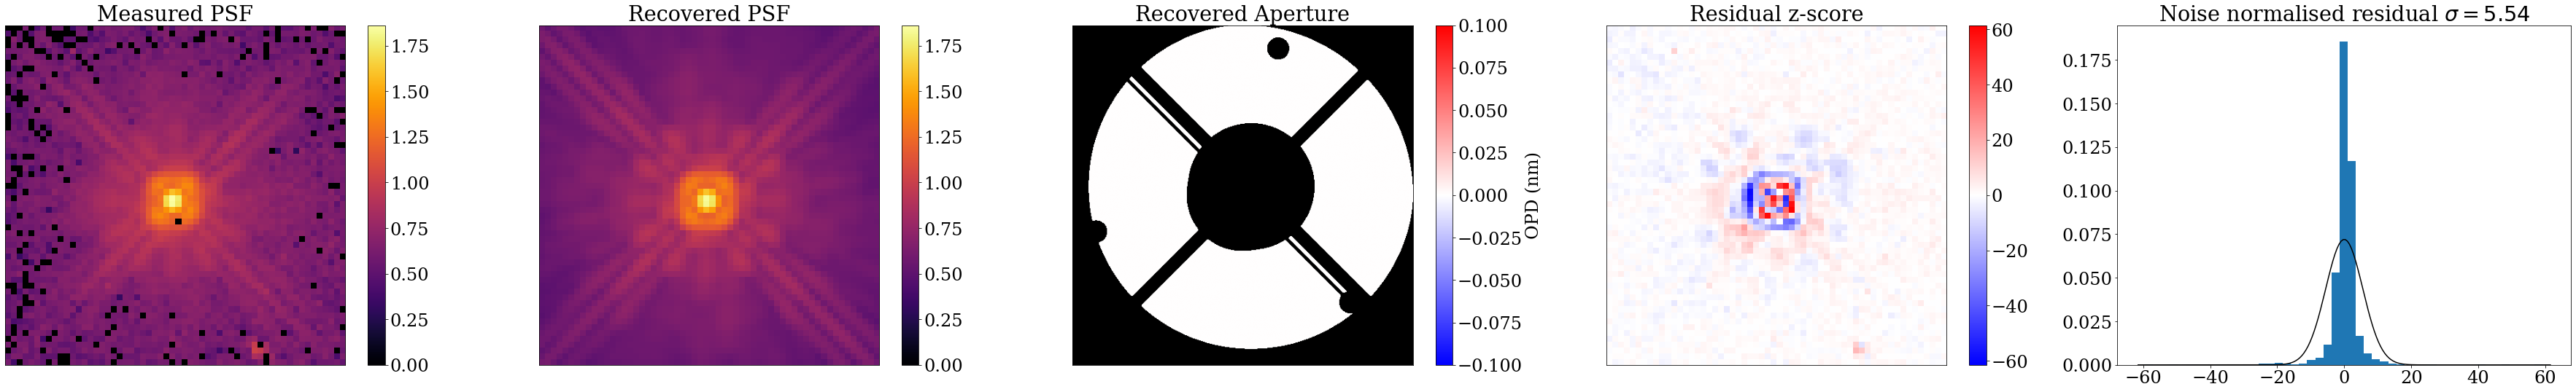

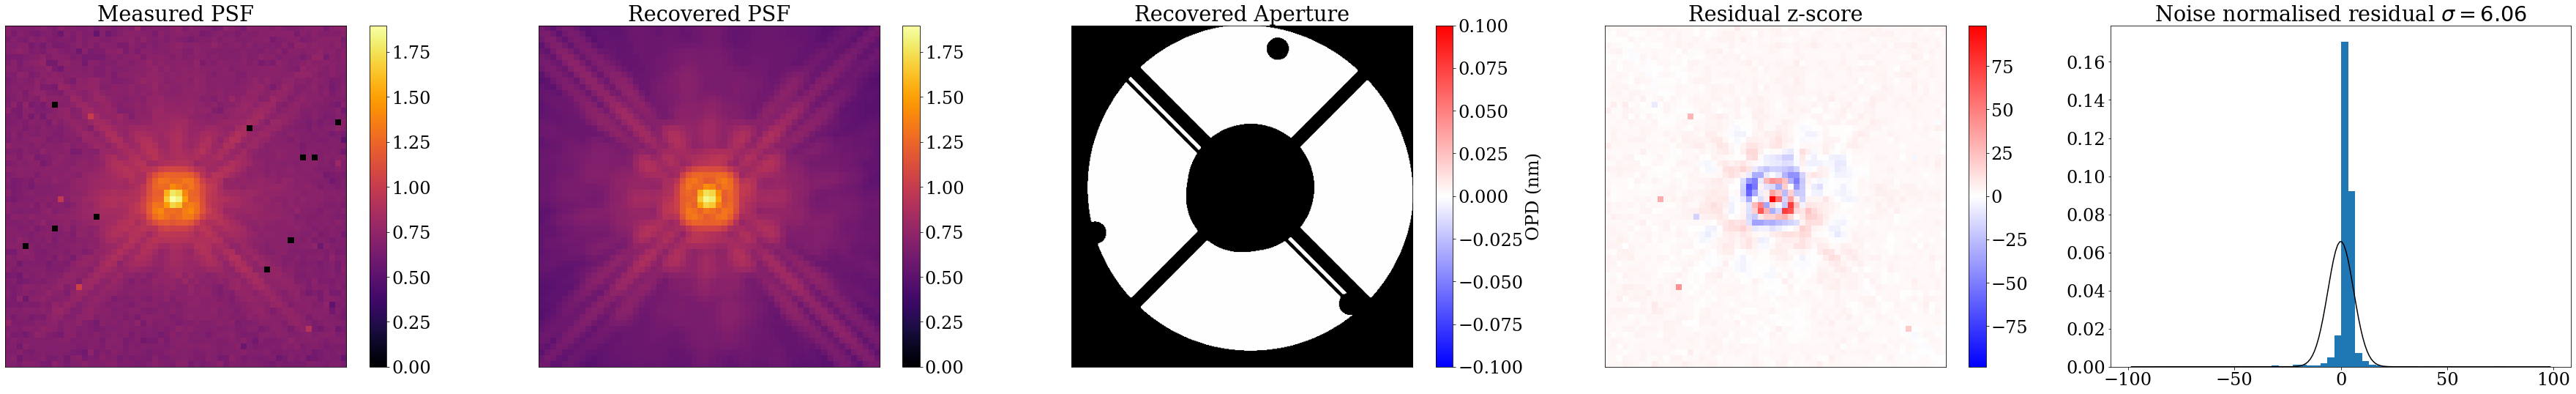

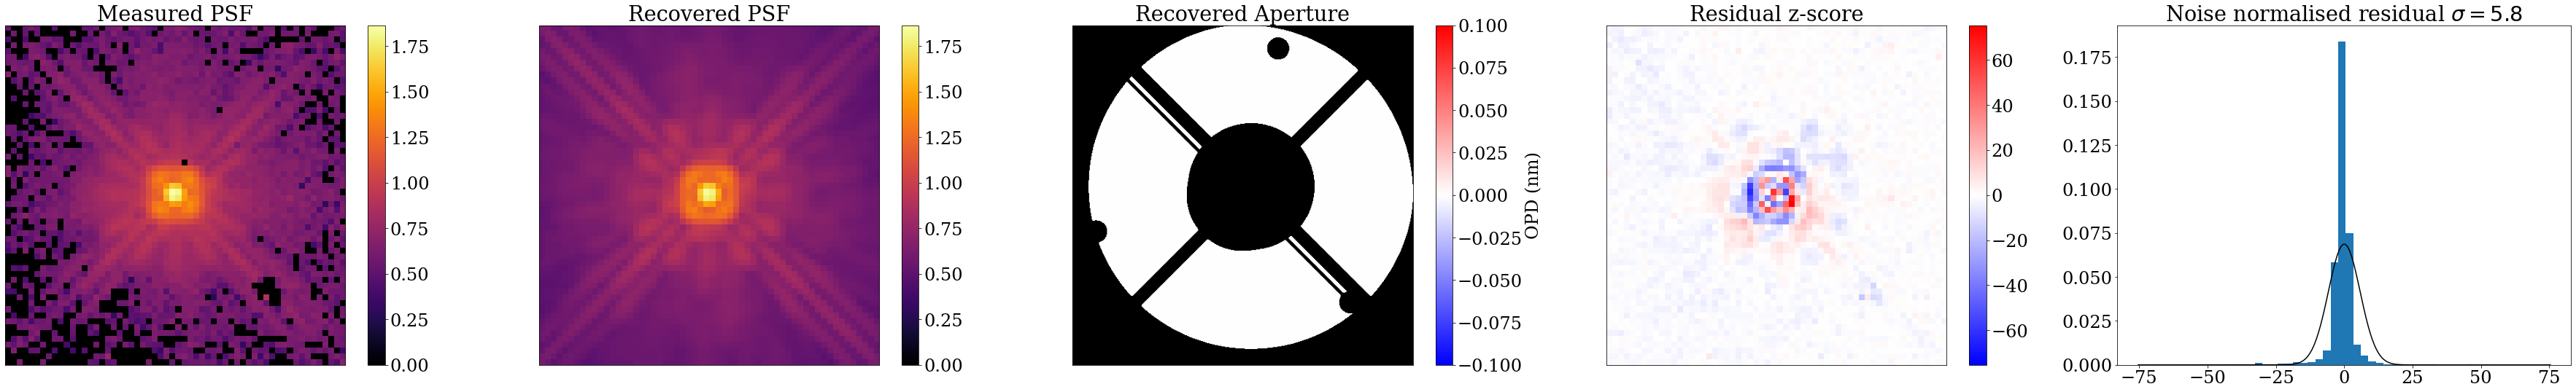

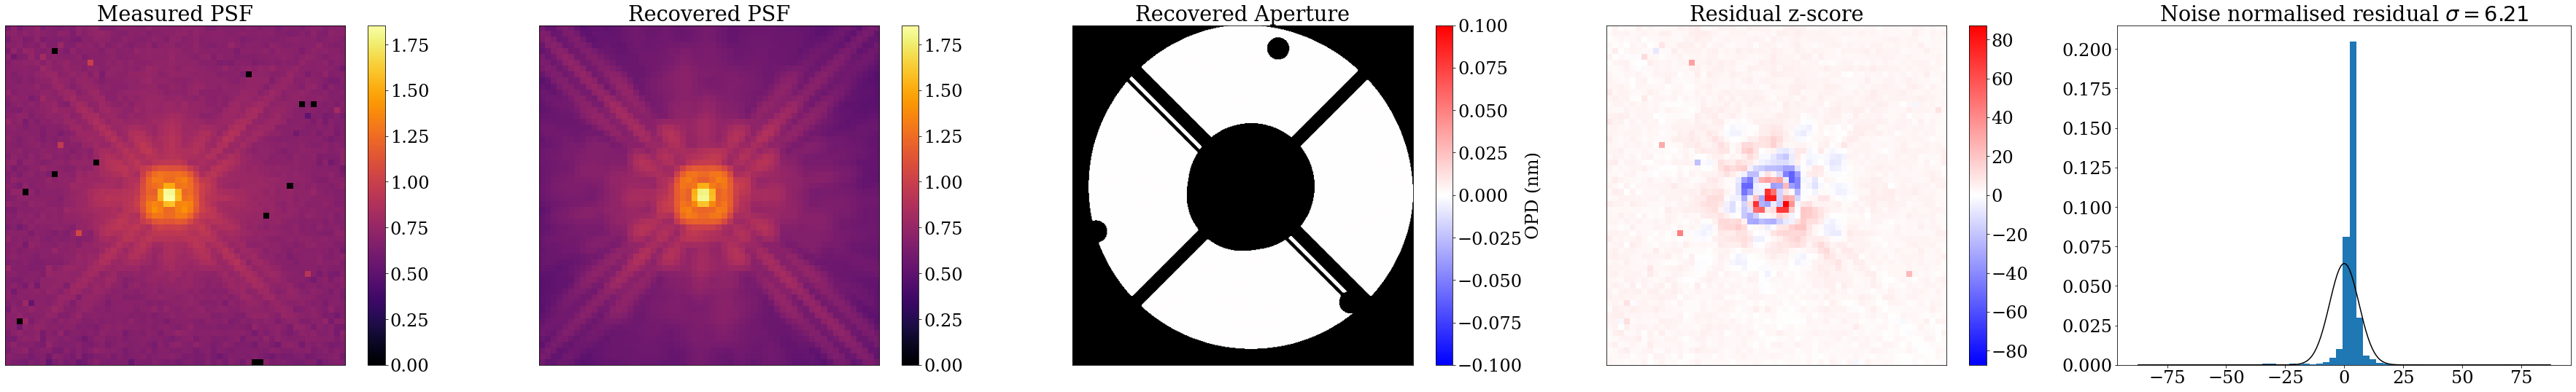

In [208]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

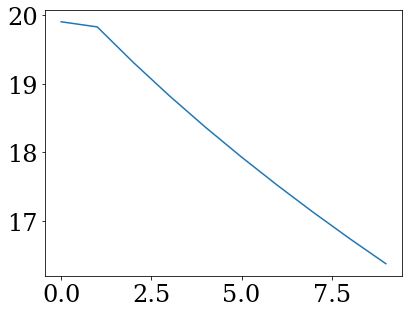

In [209]:
plt.plot(np.asarray(losses[-10:])/(len(exposures_single)*wid**2))

In [210]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [211]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=40)

  0%|          | 0/500 [00:00<?, ?it/s]

In [212]:
len(losses)

500

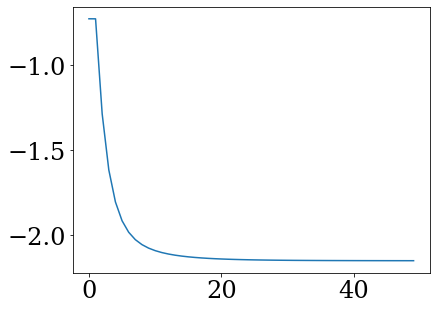

In [213]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [214]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

7
1.00196431224551
1.0146505625220914
1.0045039374988916
1.0198195000088868


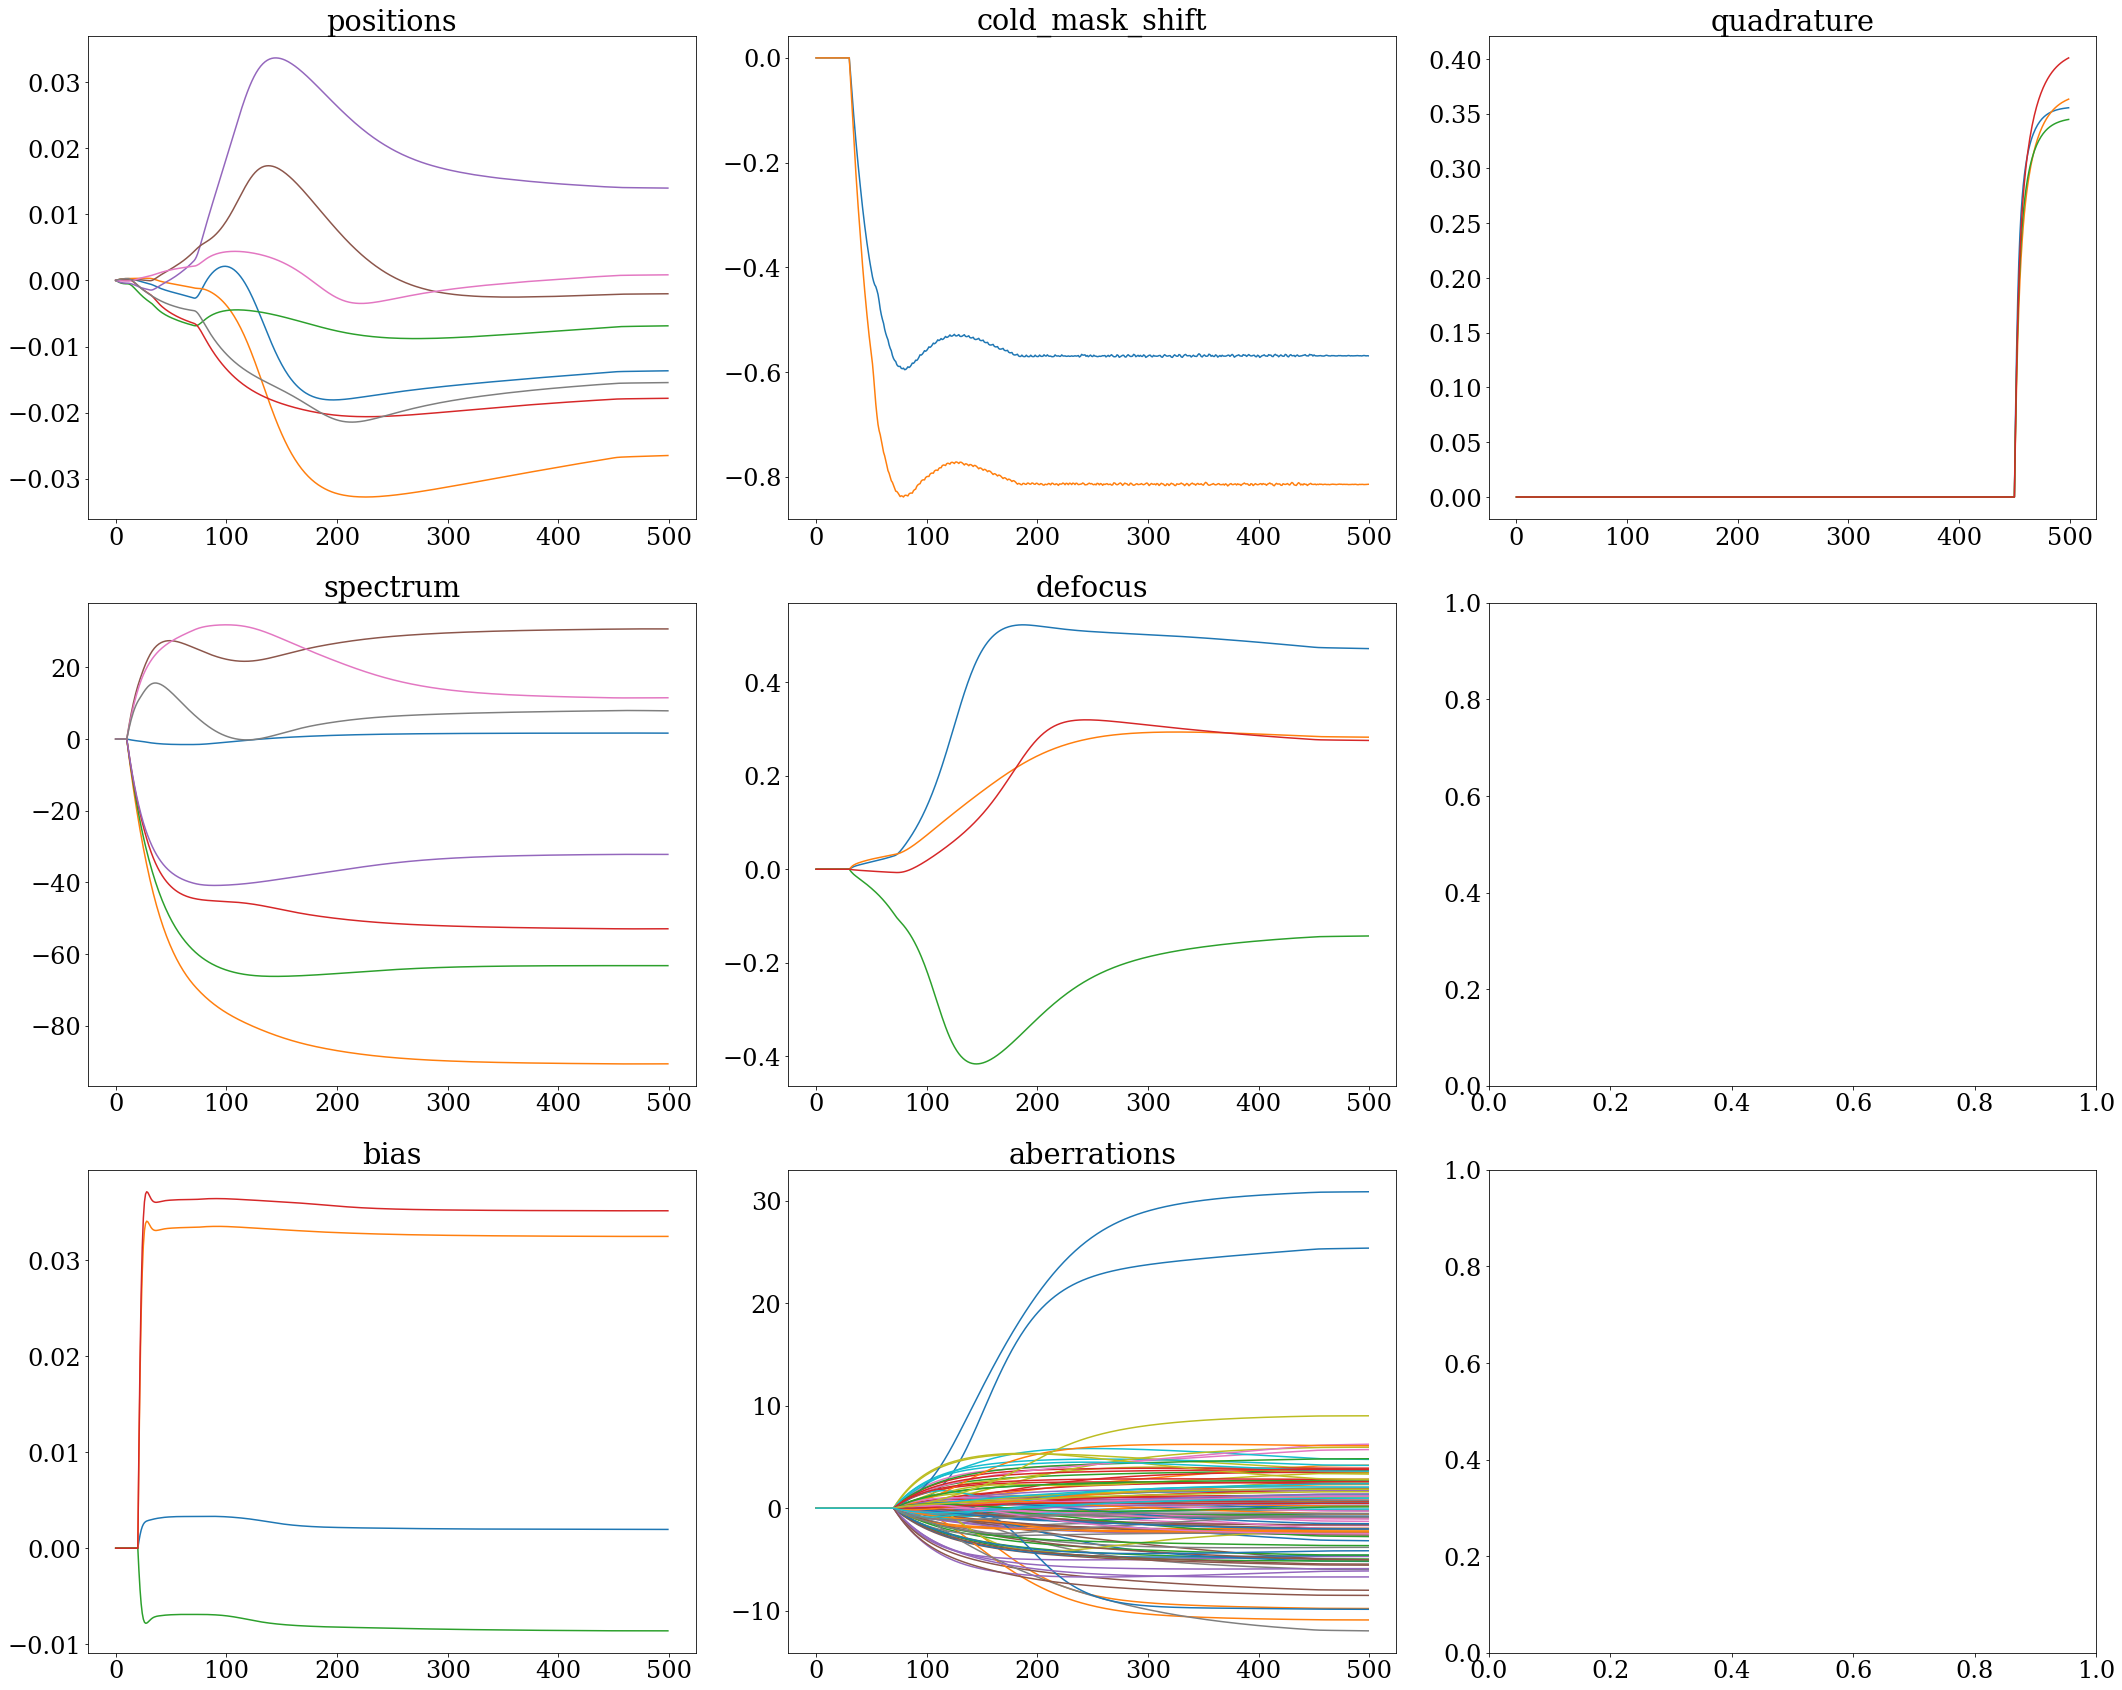

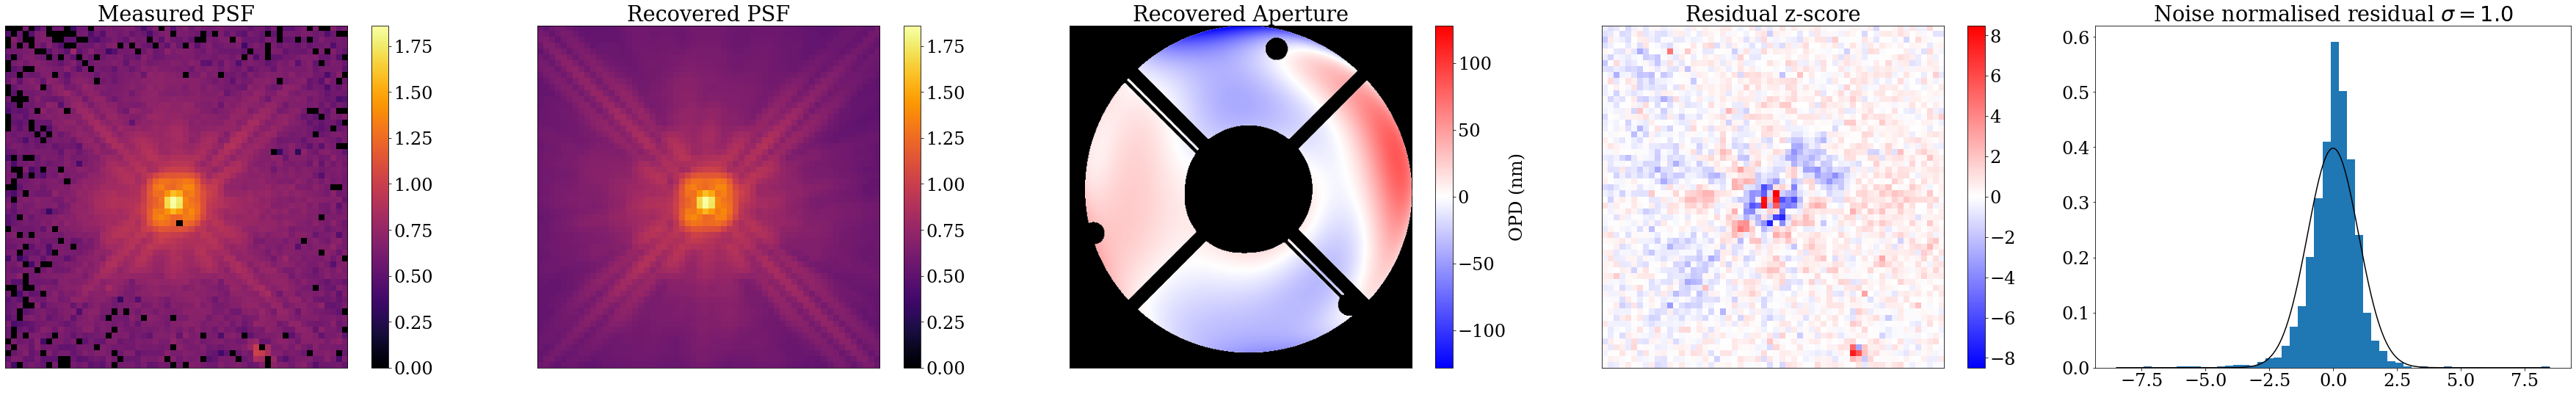

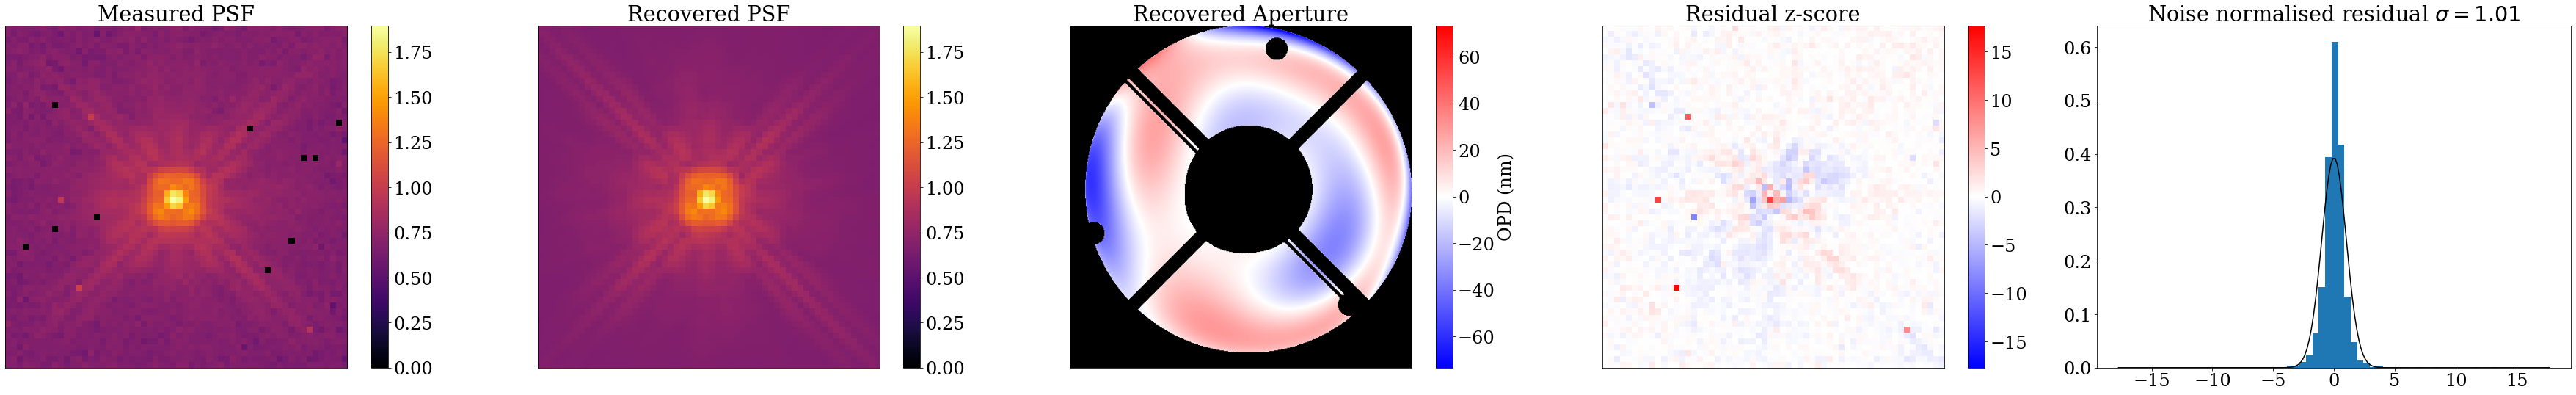

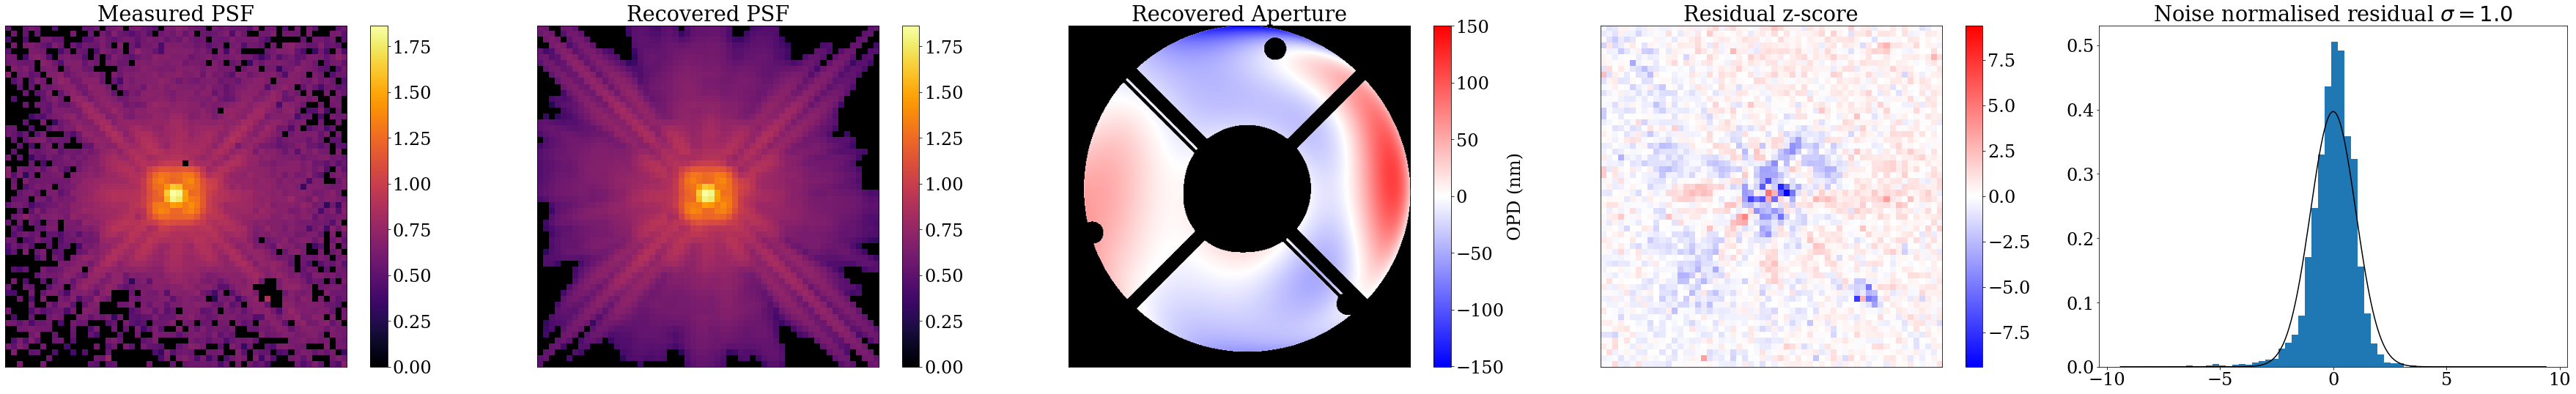

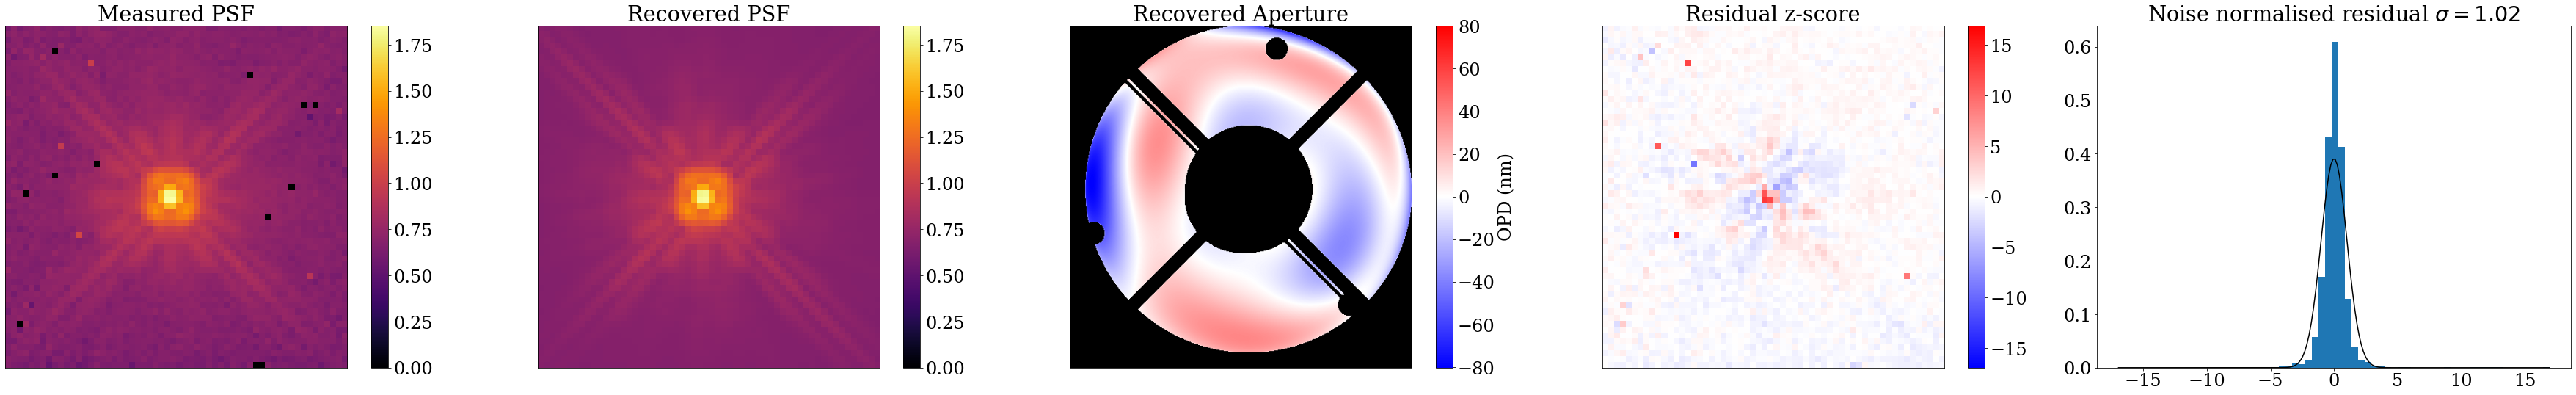

In [215]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [216]:
# final_params = ModelParams(params_history[-1])
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [217]:
final_params.params

{'aberrations': {'n8ry01tkq': Array([21.73353796, -9.91917478, -1.71899664,  8.22554774, -5.79774168,
         -9.79744345, 18.52140804, -0.95897771,  1.51853425, -8.10716135,
          2.81455272,  9.89493304, -7.99853206, -5.44230826, -1.0671545 ,
         -3.12192307,  1.57901464,  0.58094738, -2.08801462,  3.63197943,
          4.22985565, -5.94091816, -3.13884539,  2.34411237, -4.84573086,
         -3.33413382, -0.64358579, -3.12606802,  0.61231688,  0.69241232],      dtype=float64),
  'n8ry01tmq': Array([-14.70949405,  -5.62082297,  -3.03828562,   1.48074942,
          -0.6257597 , -13.30750628,   3.30383405,  -6.53833032,
          -2.49152156,  -8.44695665,  -3.09557896,  -2.42094416,
          -7.40730755,  -0.42163325,   1.46313857,  -3.99738431,
           5.20552495,  -7.51561388,  -2.2609841 ,  -6.85825517,
          -7.74404605,  -1.20339316,   7.1049461 ,   8.89659734,
          -6.78632364, -10.13000114,  -1.68269996,  -1.72770917,
           2.81005483,   0.46455812], 

In [218]:
#sol.stats

0.9996518007359918
0.9995094064590623
0.9995079823191523
0.9991077198938705


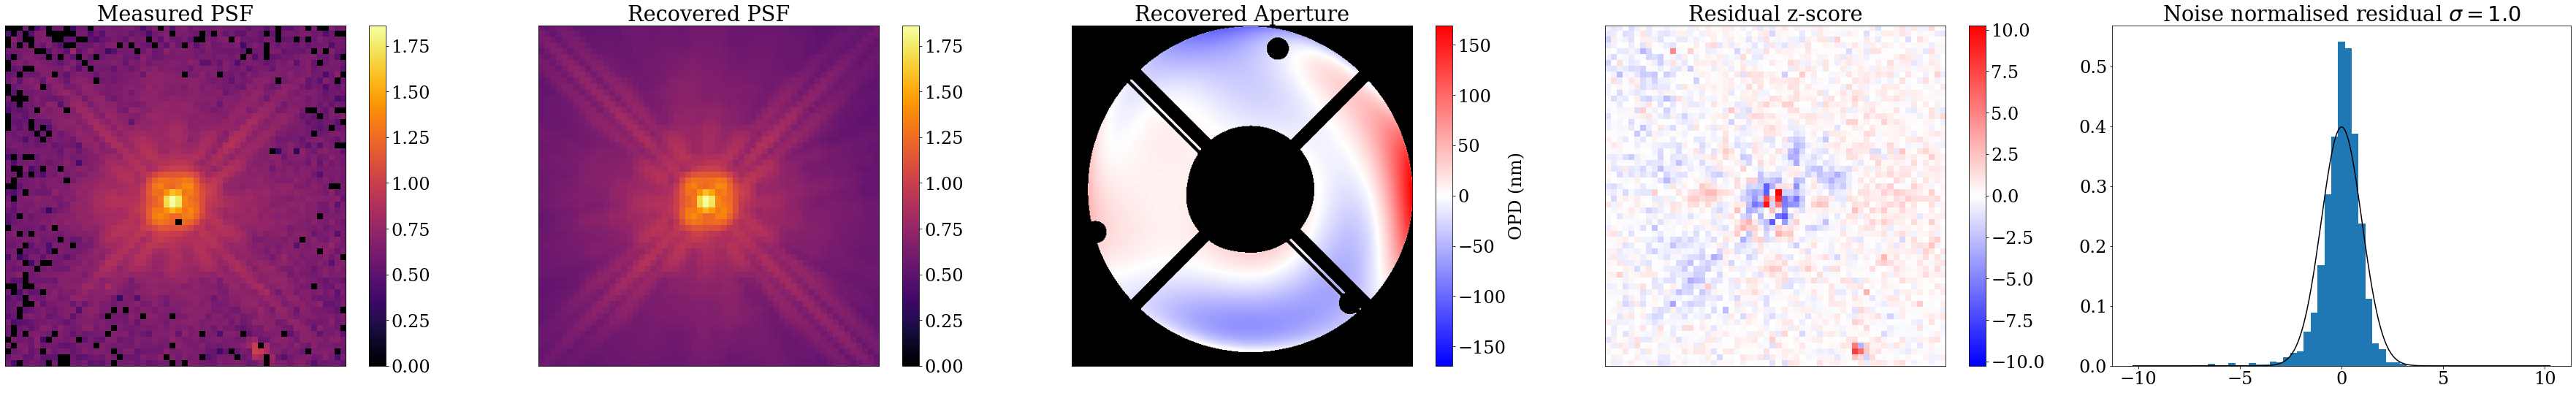

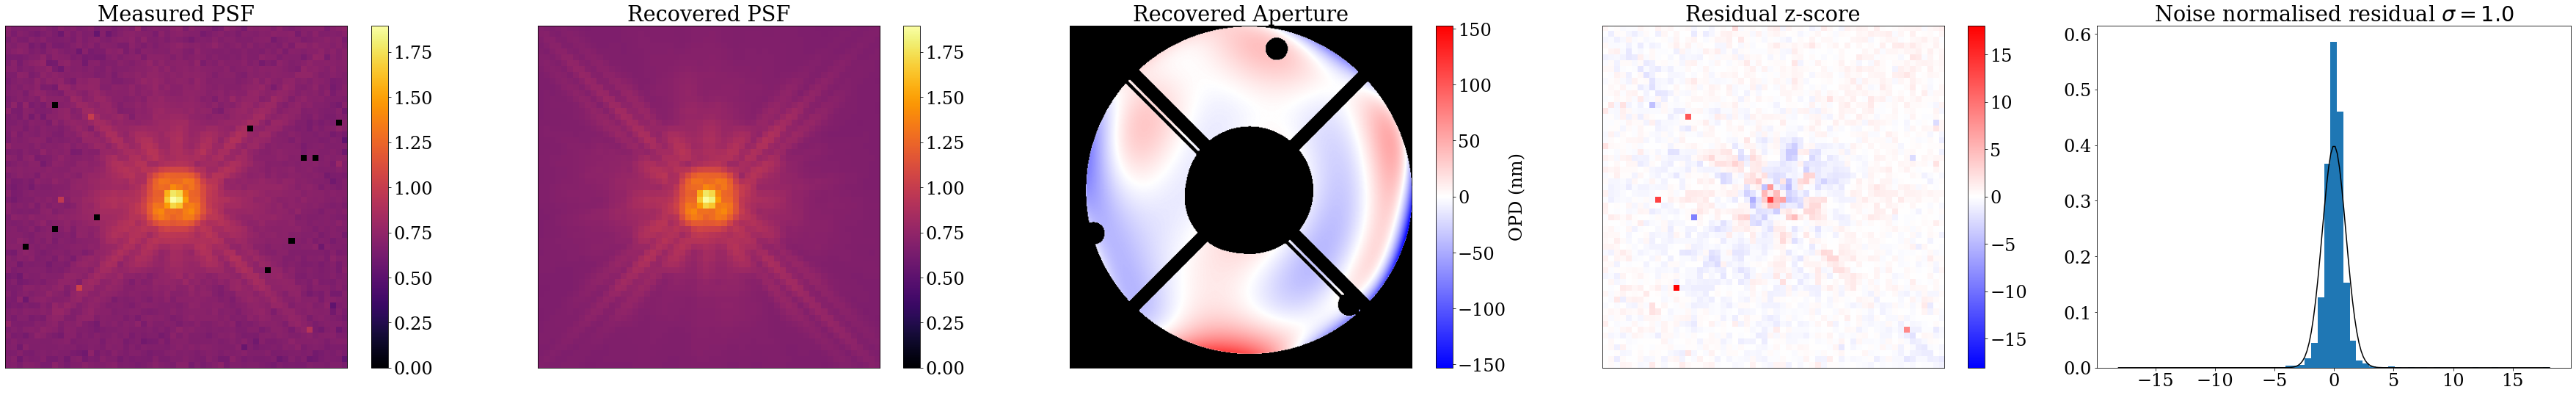

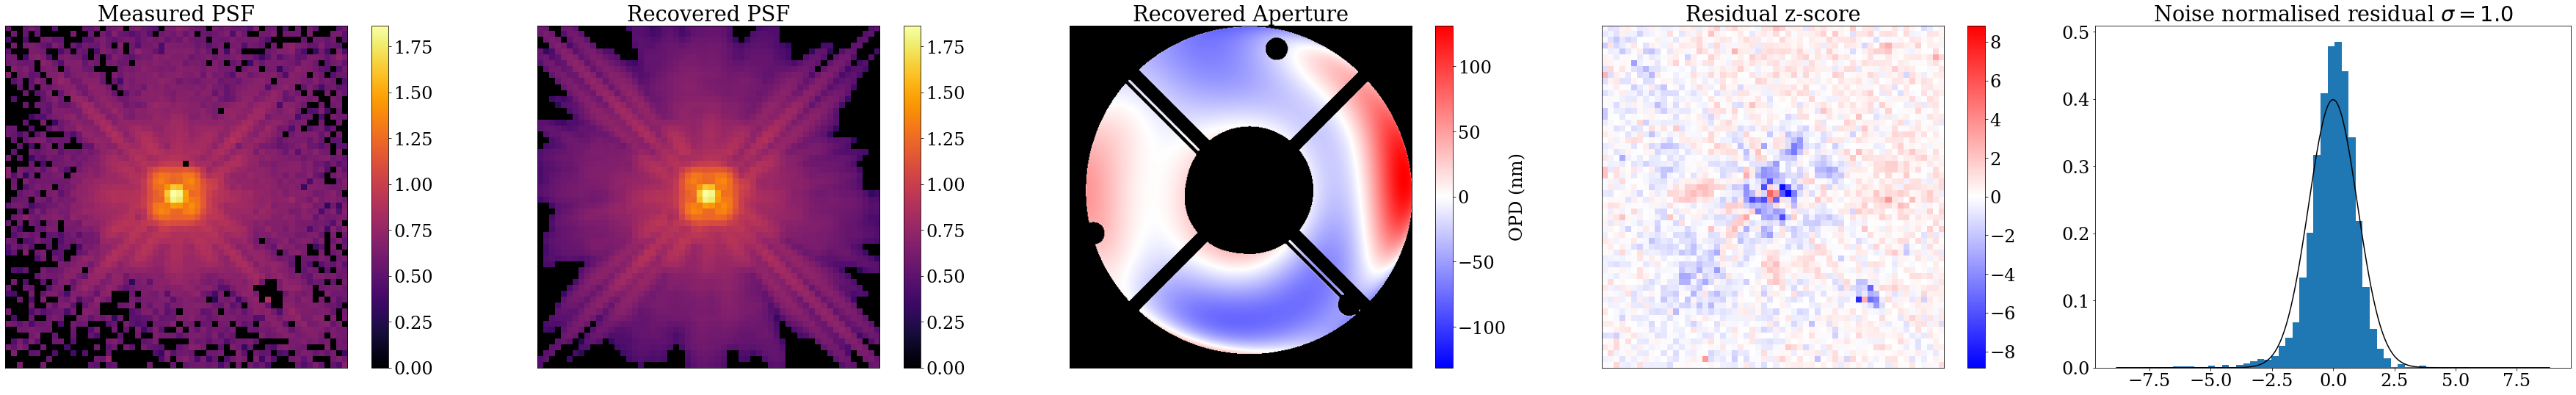

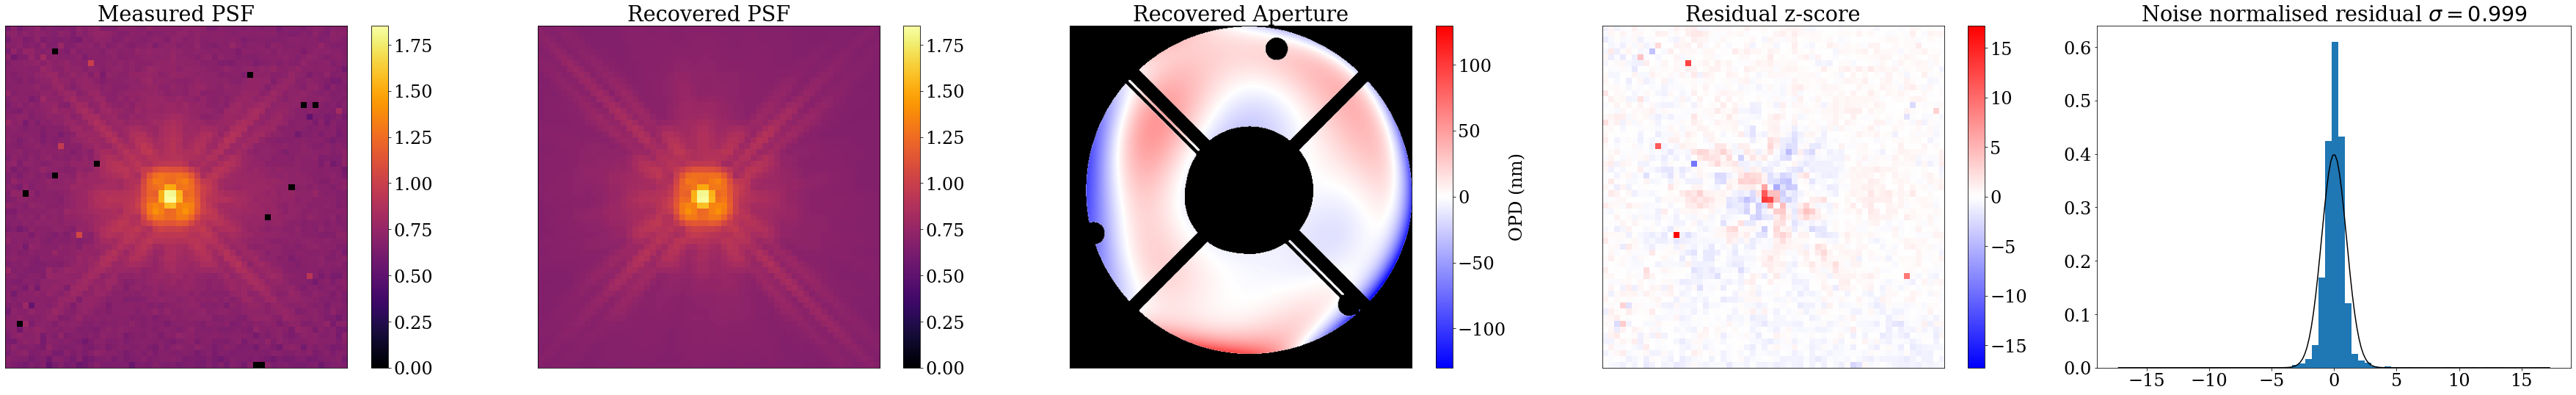

In [219]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [220]:
# calculate spectrum

In [221]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [222]:
final_params.params

{'aberrations': {'n8ry01tkq': Array([21.73353796, -9.91917478, -1.71899664,  8.22554774, -5.79774168,
         -9.79744345, 18.52140804, -0.95897771,  1.51853425, -8.10716135,
          2.81455272,  9.89493304, -7.99853206, -5.44230826, -1.0671545 ,
         -3.12192307,  1.57901464,  0.58094738, -2.08801462,  3.63197943,
          4.22985565, -5.94091816, -3.13884539,  2.34411237, -4.84573086,
         -3.33413382, -0.64358579, -3.12606802,  0.61231688,  0.69241232],      dtype=float64),
  'n8ry01tmq': Array([-14.70949405,  -5.62082297,  -3.03828562,   1.48074942,
          -0.6257597 , -13.30750628,   3.30383405,  -6.53833032,
          -2.49152156,  -8.44695665,  -3.09557896,  -2.42094416,
          -7.40730755,  -0.42163325,   1.46313857,  -3.99738431,
           5.20552495,  -7.51561388,  -2.2609841 ,  -6.85825517,
          -7.74404605,  -1.20339316,   7.1049461 ,   8.89659734,
          -6.78632364, -10.13000114,  -1.68269996,  -1.72770917,
           2.81005483,   0.46455812], 

In [223]:
# F, unflatten = zdx.batching.hessian(f, {"spectrum":params_history[-1]["spectrum"]}, nbatches=2*len(exposures_single))

In [224]:
f = lambda params: loss_fn(ModelParams(final_params.params|params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, final_params.params, nbatches=40)

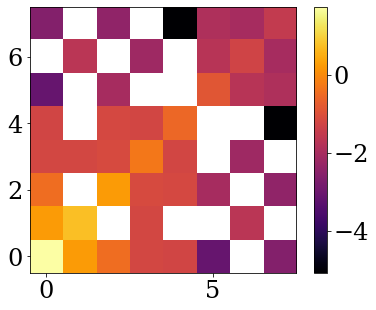

In [225]:
plt.imshow(np.log10(F[-(npoly):, -(npoly):]))
plt.colorbar()

In [226]:
np.linalg.cond(F[-(npoly):, -(npoly):])

Array(2225.53203576, dtype=float64)

In [227]:
cov_f110w = np.linalg.inv(F)[-(npoly):, -(npoly):]
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


In [228]:
final_params

ModelParams(
  params={
    'aberrations':
    {
      'n8ry01tkq': f64[30],
      'n8ry01tmq': f64[30],
      'n8ry02tpq': f64[30],
      'n8ry02tqq': f64[30]
    },
    'bias':
    {
      'n8ry01tkq': f64[],
      'n8ry01tmq': f64[],
      'n8ry02tpq': f64[],
      'n8ry02tqq': f64[]
    },
    'cold_mask_shift': {'global': f64[2]},
    'defocus':
    {
      'n8ry01tkq': f64[],
      'n8ry01tmq': f64[],
      'n8ry02tpq': f64[],
      'n8ry02tqq': f64[]
    },
    'positions':
    {
      'n8ry01tkq': f64[2],
      'n8ry01tmq': f64[2],
      'n8ry02tpq': f64[2],
      'n8ry02tqq': f64[2]
    },
    'quadrature':
    {
      'n8ry01tkq': f64[],
      'n8ry01tmq': f64[],
      'n8ry02tpq': f64[],
      'n8ry02tqq': f64[]
    },
    'spectrum': {'HZ4_F110W': f64[8]}
  }
)

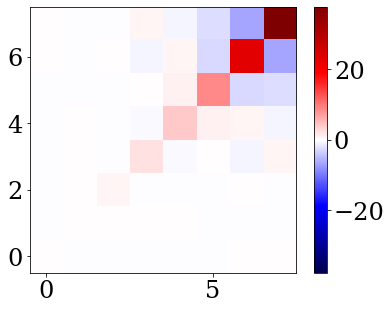

In [229]:
plt.imshow(cov_f110w, cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


In [230]:
cov2_f110w = np.linalg.inv(F)

In [231]:
np.sqrt(np.diag(cov_f110w))

Array([0.14427516, 0.49368039, 0.81520339, 1.50493037, 1.98455271,
       2.96881648, 4.78097693, 6.1423236 ], dtype=float64)

In [232]:
final_params.get("spectrum.HZ4_F110W")[:]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([1231.57056474, -210.24386674,  -93.91672659,  -45.52670091,
        -22.48491812,   15.62164141,    4.23662302,    3.74603824],      dtype=float64)

In [233]:
final_params.get("spectrum.HZ4_F110W")[0]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([1231.57056474,  359.91918707,  217.96406323,  118.0686143 ,
         89.53405123,   59.85046388,   37.16500757,   28.92798482],      dtype=float64)

In [234]:
print("mode covariances")
print(final_params.get("spectrum.HZ4_F110W")[0]/np.sqrt(np.diag(cov_f110w)))

print(final_params.get("spectrum.HZ4_F110W")[0]*np.sqrt(np.real(np.linalg.eigvals(F[-(npoly):, -(npoly):]))))


mode covariances
[1231.57056474  359.91918707  217.96406323  118.0686143    89.53405123
   59.85046388   37.16500757   28.92798482]
[1328.50818655  411.68543479  231.26149002  126.69457772   92.71845509
   63.78987866   38.90676801   28.16095054]


In [235]:
c0 = final_params.get("spectrum.HZ4_F110W")[0]
np.max((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]),axis=1)

Array([0.00081197, 0.00438346, 0.01025285, 0.02198166, 0.02729863,
       0.04734676, 0.06897829, 0.08596623], dtype=float64)

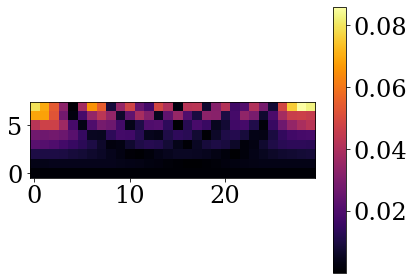

In [236]:
plt.imshow((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]))
plt.colorbar()

In [237]:
# final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(vals)

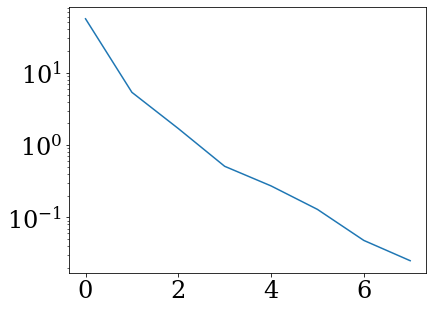

In [238]:
vals, vects = np.linalg.eig(F[-(npoly):, -(npoly):])#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [239]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels*2)

In [240]:
#final_params = ModelParams(params_history[-1])

In [241]:
fname = "2M1439.fits"
data = fits.getdata(fname, ext=0).astype(np.float32)

In [242]:
cov_f110w.shape

(8, 8)

In [243]:
keck = pd.read_csv("oned.csv")
keck_wv = keck["wavelength"].to_numpy()
keck_spec = keck["eps/thoughput"].to_numpy()

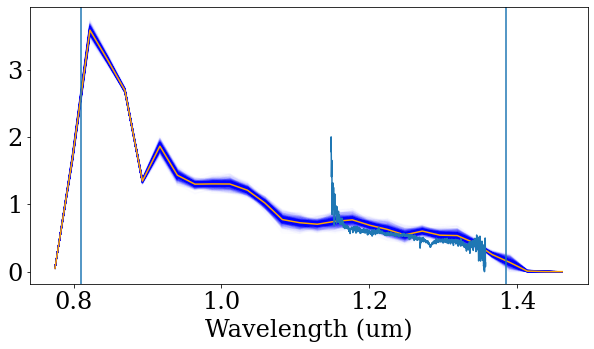

In [244]:
plt.figure(figsize=(10,5))

wv, filt = calc_throughput("F110W", nwavels=nwavels)


spec = PreCombinedBasisSpectrum(wv, final_params.get("spectrum.HZ4_F110W"), spectrum_basis)

sp = spec.spec_weights()/spec.flux/(wv*1e6)

smax = np.mean(sp)#*0.87

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F110W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wv, coeffs, spectrum_basis)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)
    # try 32nd and 68th percentile plot


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
# plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))

plt.xlabel("Wavelength (um)")
plt.axvline(0.81)
plt.axvline(1.385)
plt.plot(keck_wv/1e4, keck_spec/np.max(keck_spec)*2)

In [245]:
final_params.params

{'aberrations': {'n8ry01tkq': Array([21.73353796, -9.91917478, -1.71899664,  8.22554774, -5.79774168,
         -9.79744345, 18.52140804, -0.95897771,  1.51853425, -8.10716135,
          2.81455272,  9.89493304, -7.99853206, -5.44230826, -1.0671545 ,
         -3.12192307,  1.57901464,  0.58094738, -2.08801462,  3.63197943,
          4.22985565, -5.94091816, -3.13884539,  2.34411237, -4.84573086,
         -3.33413382, -0.64358579, -3.12606802,  0.61231688,  0.69241232],      dtype=float64),
  'n8ry01tmq': Array([-14.70949405,  -5.62082297,  -3.03828562,   1.48074942,
          -0.6257597 , -13.30750628,   3.30383405,  -6.53833032,
          -2.49152156,  -8.44695665,  -3.09557896,  -2.42094416,
          -7.40730755,  -0.42163325,   1.46313857,  -3.99738431,
           5.20552495,  -7.51561388,  -2.2609841 ,  -6.85825517,
          -7.74404605,  -1.20339316,   7.1049461 ,   8.89659734,
          -6.78632364, -10.13000114,  -1.68269996,  -1.72770917,
           2.81005483,   0.46455812], 

In [246]:
spec = PreCombinedBasisSpectrum(wv, final_params.get("spectrum.HZ4_F110W"), spectrum_basis)
np.save("spectrum_iterative.npy", spec.spec_weights())